In [28]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

### 1. What type of data does the dataset contain?
The Iris dataset is a classic "toy" dataset in machine learning that contains measurements for **150 iris flowers** from three different species:
*   **Three Species (Classes):** *Iris setosa*, *Iris versicolor*, and *Iris virginica*.
*   **Four Numerical Features:** For every flower, the dataset provides the **sepal length**, **sepal width**, **petal length**, and **petal width**, all measured in centimeters.

### 2. What are we actually trying to do?
The objective in Chapter 4 is to use this data to illustrate how **Logistic Regression** makes classification decisions. 

Initially, the we simplifies the problem to a **binary classification** task: trying to detect just one species (*Iris virginica*) based on a single feature (**petal width**).
*   **The Goal:** Build a model that takes a flower's petal width and estimates the **probability** that the flower belongs to the *Iris virginica* species.
*   **The "Why":** This allows the us to visually demonstrate the **decision boundary**. For instance, the model finds that if a flower's petal width is greater than roughly **1.6 cm**, it is more likely than not to be a *virginica*.



In [2]:
iris = load_iris(as_frame=True)

In [3]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [5]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
iris.target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [14]:
iris.target_names[iris.target]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [16]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**Next we’ll split the data and train a logistic regression model on the training set:**

In [21]:
X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y , random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Let’s look at the model’s estimated probabilities for flowers with petal widths
varying from 0 cm to 3 cm

In [25]:
X_new = np.linspace(0, 3, 100).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

In [33]:
decision_boundary

np.float64(1.6666666666666667)


#### Line 1: Creating the 1,000 fake flowers
```python
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
```
* `np.linspace(0, 3, 1000)`: This generates 1,000 perfectly evenly spaced numbers between 0 and 3. (e.g., `0.0, 0.003, 0.006, ... 2.997, 3.0`). These represent our 1,000 fake petal widths.
* `.reshape(-1, 1)`: Scikit-Learn is very strict. It demands that your input features ($X$) be a 2D grid (rows and columns). This command takes that flat list of 1,000 numbers and turns it into a tall column vector with 1,000 rows and 1 column. 

#### Line 2: Asking the model for probabilities
```python
y_proba = log_reg.predict_proba(X_new)
```
* Normally, we use `.predict()`, which just outputs `0` or `1` (Not Virginica or Virginica). 
* But here, we want to see the *exact probabilities*, so we use `.predict_proba()`.
* Because there are 2 classes (0 and 1), this outputs a grid with **two columns**:
  * **Column 0:** The probability that the flower is **NOT** Virginica.
  * **Column 1:** The probability that the flower **IS** Virginica.
* `y_proba` now holds 1,000 rows, each with two probability numbers. (e.g., `[0.95, 0.05]` means 95% chance it's not virginica, 5% chance it is).

#### Line 3: Finding the exact Decision Boundary
```python
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
```
This line looks like alien math, but it's just a series of filters. Let's read it from the inside out:

1. `y_proba[:, 1]`: This grabs **Column 1** (the probability of being Virginica) for all 1,000 fake flowers.
2. `>= 0.5`: This creates a True/False checklist. It marks `True` for every flower where the probability of being Virginica is 50% or higher.
3. `X_new[...]`: We use that True/False checklist to filter our original `X_new` list. It spits out a list of *only* the petal widths where the model predicted $\ge$ 50% chance of Virginica.


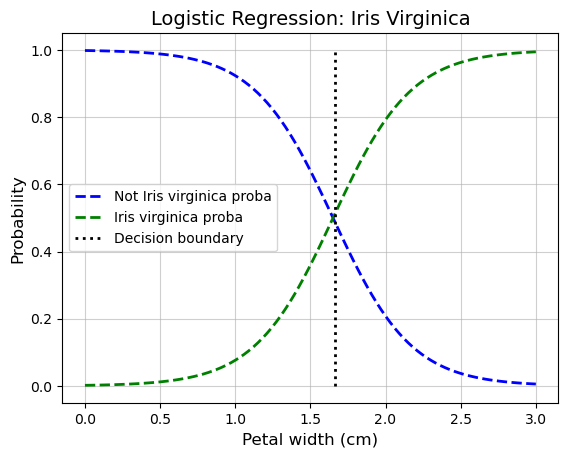

In [31]:
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g--", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")
plt.xlabel("Petal width (cm)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Logistic Regression: Iris Virginica", fontsize=14)

plt.grid(True, alpha=0.6)
plt.legend()

plt.show()

###  The Two Probability Curves

**Blue dashed line (Not Iris virginica):**
- When petal width is small (near 0 cm), the probability is **100%** that the flower is NOT virginica
- As petal width increases, this probability **decreases**

**Green dashed line (Iris virginica):**
- When petal width is small (near 0 cm), the probability is **0%** that the flower IS virginica
- As petal width increases, this probability **increases**

**Notice:** The two lines always add up to 1.0 (100%) because they are opposites!

---

### The Decision Boundary (Black Dotted Line)

This vertical line is at **~1.6-1.7 cm** (the exact number from your code above). This is the **most important part**:

- **Left of the line** (petal width < 1.6 cm): The model predicts **NOT Virginica** (blue line is higher)
- **Right of the line** (petal width > 1.6 cm): The model predicts **IS Virginica** (green line is higher)
- **Exactly on the line**: Both probabilities are 50% - the model is completely unsure!

---


 **The Sigmoid Shape:**
   - The curves are S-shaped (sigmoid). This is the signature of logistic regression!
   - The model doesn't just jump from 0 to 1; it transitions smoothly

 **The Rule:**
   - **If petal width ≥ 1.6 cm → Predict "Iris virginica"**
   - **If petal width < 1.6 cm → Predict "Not Iris virginica"**

---

### In Simple Terms:
> *"The model learned that Iris virginica flowers tend to have wider petals. If the petal is wider than about 1.6 cm, it's probably virginica. If it's narrower, it's probably not."*



In [32]:
decision_boundary

np.float64(1.6666666666666667)

In [34]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

**The hyperparameter controlling the regularization strength of a Scikit-Learn LogisticRegression
model is not alpha (as in other linear models), but its inverse: C. The higher the value of C, the less
the model is regularized.**

Just like the other linear models, logistic regression models can be regularized using
ℓ or ℓ penalties. Scikit-Learn actually adds an ℓ penalty by default

### Softmax Regression

**Softmax Regression** (also known as **Multinomial Logistic Regression**) is a generalization of the logistic regression model that supports **multiple classes** directly, rather than being limited to binary classification.

### 1. The Core Concept: How it Works
When given an input instance $\mathbf{x}$, the softmax regression model first computes a **score** $s_k(\mathbf{x})$ for each of the $K$ possible classes. 
*   **The Score (Logits):** This score is a weighted sum of the input features, calculated exactly like linear regression: $s_k(\mathbf{x}) = \theta_k^T \mathbf{x}$. 
*   **Parameter Vectors:** Crucially, **each class has its own dedicated parameter vector** ($\theta_k$), and all these vectors are typically stored as rows in a parameter matrix.
*   **Estimating Probabilities:** Once the scores (often called **logits**) are computed, the model applies the **softmax function** (or normalized exponential) to transform them into probabilities. 

### 2. The Softmax Function
The softmax function ensures that all predicted probabilities are between 0 and 1 and that they **add up to 100%** across all classes. The probability $\hat{p}_k$ that an instance belongs to class $k$ is calculated as:
$$\hat{p}_k = \sigma(\mathbf{s}(\mathbf{x}))_k = \frac{\exp(s_k(\mathbf{x}))}{\sum_{j=1}^K \exp(s_j(\mathbf{x}))}$$
The function computes the exponential of every score and then normalizes them by dividing by the sum of all the exponentials.

### 3. Making Predictions
By default, the softmax regression classifier predicts the class that has the **highest estimated probability**, which corresponds to the class that received the **highest score**. This is expressed mathematically using the **argmax** operator, which returns the value of $k$ that maximizes the function.

### 4. Training and the Cross Entropy Cost Function
The objective of training is to find the parameter matrix that results in a model estimating high probabilities for the actual target class and low probabilities for others. 
*   **Cost Function:** The model is trained by minimizing the **cross entropy** cost function. 
*   **Penalty System:** Cross entropy penalizes the model heavily when it estimates a low probability for a target class. If there are only two classes, this function is identical to the **log loss** used in logistic regression.
*   **Optimization:** Because the cross entropy cost function is convex, **Gradient Descent** (or other optimization algorithms) can be used to find the global minimum.

### 5. Important Characteristics
*   **Linear Decision Boundaries:** Similar to logistic regression, the decision boundaries between any two classes in softmax regression are always **linear**.
*   **Mutually Exclusive Classes:** Softmax regression should only be used for classes that are **mutually exclusive**, meaning an instance can belong to only one class at a time (e.g., different species of iris flowers). It is **not** suitable for multioutput tasks like recognizing multiple people in a single picture.
*   **Implementation:** In Scikit-Learn, the `LogisticRegression` class will **automatically switch to softmax regression** if you train it on more than two classes (using the default "lbfgs" solver). It also applies $\ell_2$ regularization by default, controlled by the hyperparameter $C$.

**Let’s use softmax regression to classify the iris plants into all three classes.**

In [36]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [38]:
softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [40]:
softmax_reg.predict([[5, 2]])

array([2])

In [42]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

In [43]:
softmax_reg.predict([[5, 1]])

array([1])

In [41]:
softmax_reg.predict_proba([[5, 1]]).round(2)

array([[0.  , 0.98, 0.02]])

find an iris with petals that are 5 cm long and 2 cm wide, you
can ask your model to tell you what type of iris it is, and it will answer Iris virginica
(class 2) with 98% probability (or Iris versicolor with 4% probability):

### In the Iris dataset: 0 = Setosa, 1 = Versicolor, 2 = Virginica.

* 5 = Petal length of 5 cm.
* 2 = Petal width of 2 cm.
**You are showing the model a fake flower with these exact measurements and asking it to make a prediction.**